# Zeus Geographic Scalars Heatmap

This notebook visualizes the old geographic scalar weights (`iwScore` multipliers) used by the Zeus Subnet to evaluate miners.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as mpatches

# Setup Export Directory
EXPORT_DIR = Path('../static')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print("Exports will be saved to:", EXPORT_DIR.resolve())


Exports will be saved to: /root/Zeus/static


## 1. Grid Generation and Weight Calculation


In [6]:
EUROPE_LATITUDE_RANGE = (34.0, 72.0)
EUROPE_LONGITUDE_RANGE = (-25.0, 45.0)
EUROPE_WEIGHT = 1.5

GERMANY_LATITUDE_RANGE = (47.0, 56.0)
GERMANY_LONGITUDE_RANGE = (6.0, 15.0)
GERMANY_WEIGHT = 2.5 

DEFAULT_WEIGHT = 1.0

# Generate a global grid
lats = np.linspace(90, -90, 721)
lons = np.linspace(-180, 180, 1440)
LONS, LATS = np.meshgrid(lons, lats)

# Initialize weights matrix
weights = np.full_like(LONS, DEFAULT_WEIGHT)

def apply_region_mask(weights_matrix, lat_range, lon_range, weight_value):
    lat_min, lat_max = lat_range
    lon_min, lon_max = lon_range
    
    in_lat = (LATS >= lat_min) & (LATS <= lat_max)
    in_lon = (LONS >= lon_min) & (LONS <= lon_max)
    
    mask = in_lat & in_lon
    weights_matrix = np.where(mask, np.maximum(weights_matrix, weight_value), weights_matrix)
    return weights_matrix

weights = apply_region_mask(weights, EUROPE_LATITUDE_RANGE, EUROPE_LONGITUDE_RANGE, EUROPE_WEIGHT)
weights = apply_region_mask(weights, GERMANY_LATITUDE_RANGE, GERMANY_LONGITUDE_RANGE, GERMANY_WEIGHT)


## 2. Scientific Visualization and Export


Exported to ../static/zeus_geographic_scalars.png


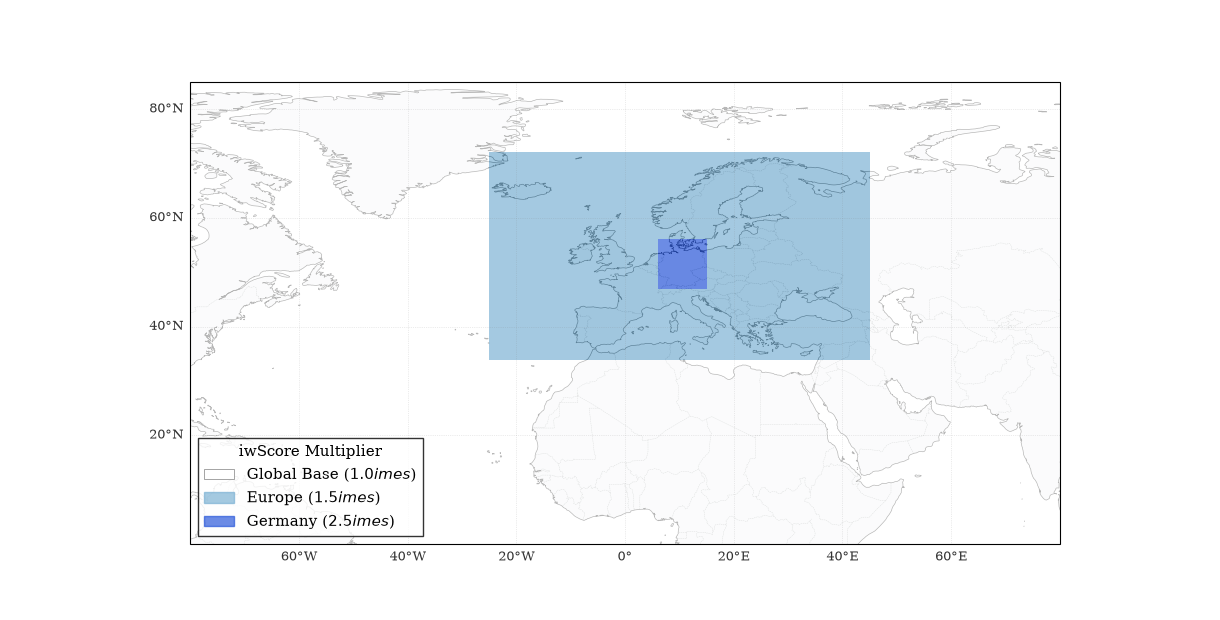

In [7]:
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.titlesize': 16
})


fig = plt.figure(figsize=(12, 6))

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))


ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='#f4f6f8'), zorder=0)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'ocean', '50m', edgecolor='face', facecolor='#ffffff'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.3, edgecolor='#999999', linestyle='--', zorder=0)
ax.coastlines(resolution='50m', linewidth=0.5, color='#333333', zorder=1)

cmap = ListedColormap(['#ffffff00', '#74add1', '#1d4ed8'])
bounds = [0.5, 1.25, 2.0, 3.0]
norm = BoundaryNorm(bounds, cmap.N)


img = ax.pcolormesh(LONS, LATS, weights, transform=ccrs.PlateCarree(), 
                    cmap=cmap, norm=norm, shading='auto', alpha=0.65, zorder=2)


gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.3, linestyle=':')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9, 'color': '#333333'}
gl.ylabel_style = {'size': 9, 'color': '#333333'}

ax.set_extent([-80, 80, 0, 85], crs=ccrs.PlateCarree())

global_patch = mpatches.Patch(color='#ffffff', label='Global Base ($1.0\times$)', ec='gray', lw=0.5)
europe_patch = mpatches.Patch(color='#74add1', label='Europe ($1.5\times$)', alpha=0.65)
germany_patch = mpatches.Patch(color='#1d4ed8', label='Germany ($2.5\times$)', alpha=0.65)

ax.legend(handles=[global_patch, europe_patch, germany_patch], 
          loc='lower left', 
          frameon=True, 
          fancybox=False, 
          edgecolor='black',
          title="iwScore Multiplier")

plt.title('Zeus Geographic Scalar Distribution', pad=20, weight='bold')


png_path = EXPORT_DIR / 'zeus_geographic_scalars.png'

plt.savefig(png_path, dpi=300, bbox_inches='tight')

print(f"Exported to {png_path}")

plt.show()
